In [5]:
import os
import sys
import torch
from pathlib import Path
from tqdm import tqdm
from hydra.utils import instantiate
from omegaconf import OmegaConf
from collections import defaultdict
import contextlib
import io

# --- NOTES ---
# logs/train/multiruns/2026-01-16_09-39-58: WRN(40-4), de M=10, cifar10
# logs/train/multiruns/2026-01-17_10-00-09: WRN(28-10), de M=10, cifar10

# --- CONFIGURATION ---
PROJECT_PATH = Path.cwd().parent.resolve()
if str(PROJECT_PATH) not in sys.path:
    sys.path.insert(0, str(PROJECT_PATH))
os.environ["PROJECT_ROOT"] = str(PROJECT_PATH)
from src.utils.uncertainty import TotalUncertainty, AleatoricUncertainty, EpistemicUncertainty
BASE_PATH = Path(PROJECT_PATH / "logs/train/multiruns/2026-01-17_10-00-09")
IDX_RANGE = range(40) 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model_from_run(idx):
    run_dir = BASE_PATH / str(idx)
    # Search for config in common Hydra/Lightning locations
    config_path = run_dir / "csv" / "version_0" / "hparams.yaml"
    if not config_path:
        raise FileNotFoundError(f"No config found for idx {idx}")
    
    cfg = OmegaConf.load(config_path)
    cfg.data.data_dir = str(PROJECT_PATH / "data")

    model = instantiate(cfg.model)

    ckpt_path = list(run_dir.glob("**/*.ckpt"))[0]
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['state_dict'])
    
    return model.to(DEVICE).eval(), cfg

# --- DATA LOADING ---
print("Initializing Data Loader...")
_, first_cfg = load_model_from_run(0)
datamodule = instantiate(first_cfg.data)
datamodule.setup(stage="test")
test_loader = datamodule.test_dataloader()

# --- INFERENCE & GROUPED STORAGE ---
# Storage: { subset_size: [ { "seed": int, "probs": Tensor }, ... ] }
grouped_results = defaultdict(list)
true_labels = []

print(f"Processing models from {BASE_PATH}...")

for idx in tqdm(IDX_RANGE, desc="Evaluating Runs"):
    try:
        model, cfg = load_model_from_run(idx)
        
        # Identify which subset this model belongs to
        subset_size = cfg.data.get("train_subset", "unknown")
        seed_val = cfg.get("seed", "unknown")
        
        model_probs = []
        with torch.no_grad():
            for x, y in test_loader:
                if idx == 0:
                    true_labels.append(y)
                
                logits = model(x.to(DEVICE))
                probs = torch.softmax(logits, dim=1)
                model_probs.append(probs.cpu())
        
        # Save to the specific subset group
        grouped_results[subset_size].append({
            "seed": seed_val,
            "probs": torch.cat(model_probs)
        })
        
        # Cleanup
        del model
        torch.cuda.empty_cache()
        
    except Exception as e:
        print(f"Skipping index {idx}: {e}")

y_true = torch.cat(true_labels) if true_labels else None

Initializing Data Loader...
Creating training subset of 12500 samples from dataset of size 50000
Processing models from /home/rossom/hydra-experiments/logs/train/multiruns/2026-01-17_10-00-09...


Evaluating Runs: 100%|██████████| 40/40 [02:13<00:00,  3.35s/it]


In [6]:
# --- FINAL ANALYSIS WITH UNCERTAINTY ---
print("\n" + "="*85)
print(f"{'SUBSET':<10} | {'ACC':<8} | {'TU':<12} | {'AU':<10} | {'EU':<10}")
print("-" * 85)

results_summary = {}

for subset, models_data_list in grouped_results.items():
    probs = [m['probs'] for m in models_data_list]
    mcd_preds = torch.stack(probs) # [M, N, C]

    
    # Initialize your custom metrics
    total_metric = TotalUncertainty()
    aleatoric_metric = AleatoricUncertainty()
    epistemic_metric = EpistemicUncertainty(total_metric, aleatoric_metric)

    # Update metrics 
    # Since metrics are batch-based, we feed the full ensemble as one large "batch"
    # mcd_preds is [M, N, C]. Metrics expect [T, B, C]
    epistemic_metric.update(mcd_preds, probs=True)

    # Calculate Ensemble Accuracy
    mean_probs = mcd_preds.mean(dim=0)
    preds = torch.argmax(mean_probs, dim=1)
    acc = (preds == y_true).float().mean().item()

    # Compute Uncertainties
    u_total = total_metric.compute().item()
    u_aleatoric = aleatoric_metric.compute().item()
    u_epistemic = epistemic_metric.compute().item()

    print(f"{str(subset):<10} | {acc*100:>6.2f}% | {u_total:>11.4f} | {u_aleatoric:>9.4f} | {u_epistemic:>9.4f}")

    results_summary[subset] = {
        "accuracy": acc,
        "total": u_total,
        "aleatoric": u_aleatoric,
        "epistemic": u_epistemic
    }


SUBSET     | ACC      | TU           | AU         | EU        
-------------------------------------------------------------------------------------
12500      |  85.12% |      0.4156 |    0.1334 |    0.2823
25000      |  89.04% |      0.2714 |    0.0857 |    0.1856
37500      |  90.86% |      0.2119 |    0.0711 |    0.1408
50000      |  92.25% |      0.1582 |    0.0495 |    0.1087


In [7]:
import pandas as pd
# Convert dictionary to list of records
data_for_df = []
for subset, metrics in results_summary.items():
    row = {"subset_size": int(subset)}
    row.update(metrics)
    data_for_df.append(row)

# Create DataFrame and sort by subset size for plotting
df_results = pd.DataFrame(data_for_df).sort_values("subset_size")

# Display the table
print("Final Scaling Results:")
print(df_results)

# Optional: Save to CSV
df_results.to_csv("wrn-28-10_deM10.csv", index=False)

Final Scaling Results:
   subset_size  accuracy     total  aleatoric  epistemic
0        12500    0.8512  0.415648   0.133396   0.282252
1        25000    0.8904  0.271369   0.085735   0.185634
2        37500    0.9086  0.211910   0.071106   0.140804
3        50000    0.9225  0.158223   0.049530   0.108693


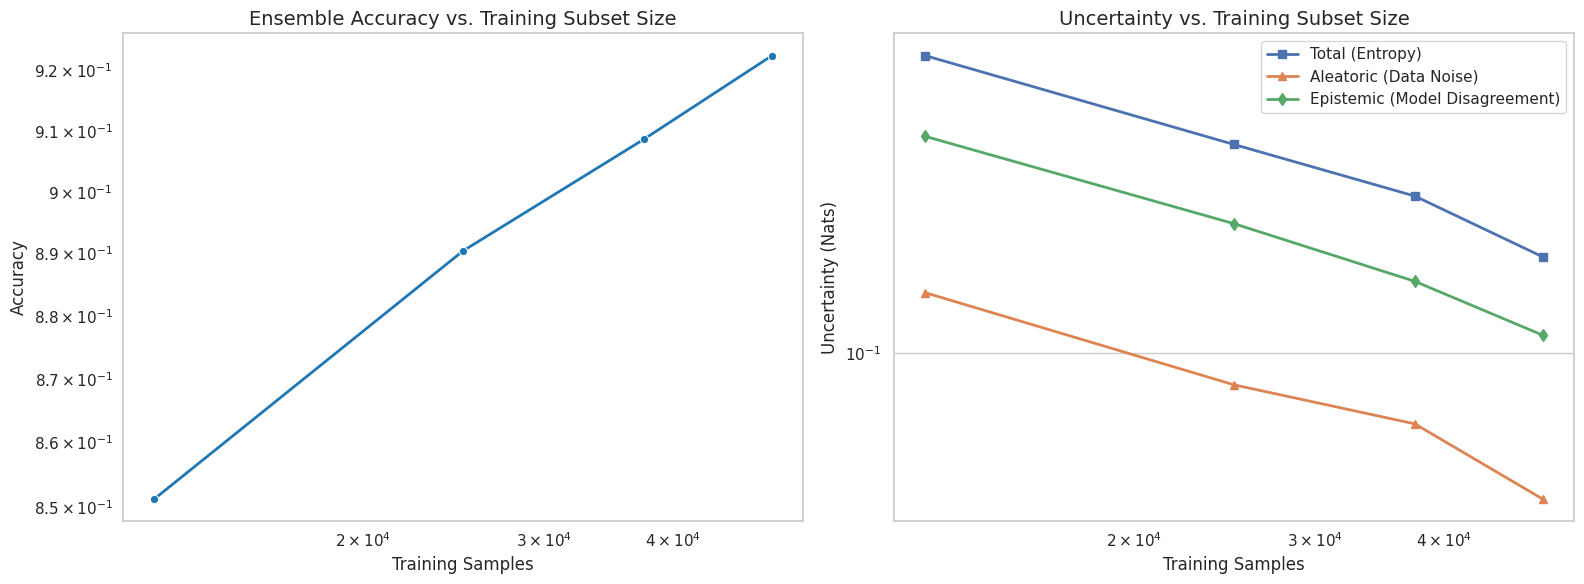

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Ensemble Accuracy ---
sns.lineplot(data=df_results, x="subset_size", y="accuracy", marker="o", ax=ax1[0], color="tab:blue", lw=2)
ax1[0].set_title("Ensemble Accuracy vs. Training Subset Size", fontsize=14)
ax1[0].set_xlabel("Training Samples", fontsize=12)
ax1[0].set_ylabel("Accuracy", fontsize=12)
ax1[0].set_xscale("log")
ax1[0].set_yscale("log")


# --- Plot 2: Uncertainty Decomposition ---
ax1[1].plot(df_results["subset_size"], df_results["total"], label="Total (Entropy)", marker="s", lw=2)
ax1[1].plot(df_results["subset_size"], df_results["aleatoric"], label="Aleatoric (Data Noise)", marker="^", lw=2)
ax1[1].plot(df_results["subset_size"], df_results["epistemic"], label="Epistemic (Model Disagreement)", marker="d", lw=2)

ax1[1].set_title("Uncertainty vs. Training Subset Size", fontsize=14)
ax1[1].set_xlabel("Training Samples", fontsize=12)
ax1[1].set_ylabel("Uncertainty (Nats)", fontsize=12)
ax1[1].set_xscale("log")
ax1[1].set_yscale("log")
ax1[1].legend()

plt.tight_layout()
plt.show()